In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

## 1. Problem Statement
#### To predict price(dependent variable) of vehicle by using various independent parameters

## Data gathering

In [2]:
df = pd.read_csv(r"C:\Users\midha\Downloads\Auto Data Set.csv")
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [3]:
df.head().T  #Show first 5 rows and then rotate the table 

,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,?,?,?,164,164
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
engine-location,front,front,front,front,front
wheel-base,88.6,88.6,94.5,99.8,99.4


In [4]:
df.shape   #size of the dataframe(rows,colunms)

(205, 26)

In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [6]:
df['num-of-cylinders'].value_counts()

num-of-cylinders
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

## Encoding
#### 1.Label Encoding
#### 2.One Hot Encoding
#### 3.Hash Encoding
#### 4.Binary Enconding

## 1. Label Encoding

#### High Medium Low
#### High >> 2
#### Medium >> 1
#### Low >> 0

In [7]:
df['num-of-cylinders'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [8]:
df['num-of-cylinders'].replace({'four':4, 'six':6, 'five':5, 'three':3, 
                     'twelve':12, 'two':2, 'eight':8}, inplace=True)

C:\Users\midha\AppData\Local\Temp\ipykernel_8652\4098979023.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['num-of-cylinders'].replace({'four':4, 'six':6, 'five':5, 'three':3,
C:\Users\midha\AppData\Local\Temp\ipykernel_8652\4098979023.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['

In [9]:
df['num-of-cylinders'].unique()

array([ 4,  6,  5,  3, 12,  2,  8])

In [10]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [11]:
df['num-of-cylinders'].unique()

array([ 4,  6,  5,  3, 12,  2,  8])

In [12]:
labelEnc = LabelEncoder()
labelEnc.fit_transform(df['num-of-cylinders'])

array([2, 2, 4, 2, 3, 3, 3, 3, 3, 3, 2, 2, 4, 4, 4, 4, 4, 4, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 4, 4, 6, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 5, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 4, 4, 2])

In [13]:
df['num-of-cylinders']

0      4
1      4
2      6
3      4
4      5
      ..
200    4
201    4
202    6
203    6
204    4
Name: num-of-cylinders, Length: 205, dtype: int64

In [14]:
l1 = ['four', 'six', 'five', 'three', 'twelve', 'two', 'eight']
sorted(l1)

['eight', 'five', 'four', 'six', 'three', 'twelve', 'two']

In [15]:
df_test = pd.DataFrame({'Test': ['Low', 'Medium', 'High', 'Medium','Low', 'Medium','Low']})
df_test
labelEnc.fit_transform(df_test['Test'])
df_test

,Test
0,Low
1,Medium
2,High
3,Medium
4,Low
5,Medium
6,Low


In [72]:
df_test['Test'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [74]:
df_test['Test'].replace({'Low':0, 'Medium':1, 'High':2}, inplace= True)

In [18]:
df_test['Test'].unique()

array([0, 1, 2])

In [19]:
df_test['Test']

0    0
1    1
2    2
3    1
4    0
5    1
6    0
Name: Test, dtype: int64

#### One Hot Encoding
Gender
            Female     Male
Male          0         1
Female        1         0
Female        1         0
Male          0         1
Male          0         1
Female        1         0


In [20]:
df_test = pd.DataFrame({'Test': ['Low', 'Medium', 'High', 'Medium','Low', 'Medium','Low']})

In [21]:
df_test

,Test
0,Low
1,Medium
2,High
3,Medium
4,Low
5,Medium
6,Low


In [22]:
df_new = pd.get_dummies(df_test, columns=['Test'], prefix = 'Test')
df_new

,Test_High,Test_Low,Test_Medium
0,False,True,False
1,False,False,True
2,True,False,False
3,False,False,True
4,False,True,False
5,False,False,True
6,False,True,False


In [23]:
df_test = pd.DataFrame({'Test': ['Low', 'Medium', 'High', 'Medium','Low', 'Medium','Low']})
df_new = pd.get_dummies(df_test, columns=['Test'], prefix = 'Test', drop_first=True)
df_new

,Test_Low,Test_Medium
0,True,False
1,False,True
2,False,False
3,False,True
4,True,False
5,False,True
6,True,False


In [24]:
oneHotEnc = OneHotEncoder()
df_onehot = pd.DataFrame(oneHotEnc.fit_transform(df_test[['Test']]).toarray(),dtype=int)
df_onehot

,0,1,2
0,0,1,0
1,0,0,1
2,1,0,0
3,0,0,1
4,0,1,0
5,0,0,1
6,0,1,0


In [25]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [26]:
df.replace('?', np.nan, inplace=True)
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    int64  
 16  engine-size        205 non

In [28]:
df.isna().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [29]:
df.drop(['make','fuel-type','aspiration','num-of-doors','body-style','drive-wheels',
        'engine-location','fuel-system'],axis = 1, inplace=True)

In [30]:
df

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,94.5,171.2,65.5,52.4,2823,ohcv,6,152,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,99.8,176.6,66.2,54.3,2337,ohc,4,109,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,99.4,176.6,66.4,54.3,2824,ohc,5,136,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,109.1,188.8,68.9,55.5,2952,ohc,4,141,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,109.1,188.8,68.8,55.5,3049,ohc,4,141,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,109.1,188.8,68.9,55.5,3012,ohcv,6,173,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,109.1,188.8,68.9,55.5,3217,ohc,6,145,3.01,3.4,23.0,106,4800,26,27,22470


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   wheel-base         205 non-null    float64
 3   length             205 non-null    float64
 4   width              205 non-null    float64
 5   height             205 non-null    float64
 6   curb-weight        205 non-null    int64  
 7   engine-type        205 non-null    object 
 8   num-of-cylinders   205 non-null    int64  
 9   engine-size        205 non-null    int64  
 10  bore               201 non-null    object 
 11  stroke             201 non-null    object 
 12  compression-ratio  205 non-null    float64
 13  horsepower         203 non-null    object 
 14  peak-rpm           203 non-null    object 
 15  city-mpg           205 non-null    int64  
 16  highway-mpg        205 non

In [32]:
df['normalized-losses'] = df['normalized-losses'].astype('float')
df['bore'] = df['bore'].astype('float')
df['stroke'] = df['stroke'].astype('float')
df['horsepower'] = df['horsepower'].astype('float')
df['peak-rpm'] = df['peak-rpm'].astype('float')
df['price'] = df['price'].astype('float')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   wheel-base         205 non-null    float64
 3   length             205 non-null    float64
 4   width              205 non-null    float64
 5   height             205 non-null    float64
 6   curb-weight        205 non-null    int64  
 7   engine-type        205 non-null    object 
 8   num-of-cylinders   205 non-null    int64  
 9   engine-size        205 non-null    int64  
 10  bore               201 non-null    float64
 11  stroke             201 non-null    float64
 12  compression-ratio  205 non-null    float64
 13  horsepower         203 non-null    float64
 14  peak-rpm           203 non-null    float64
 15  city-mpg           205 non-null    int64  
 16  highway-mpg        205 non

In [34]:
df


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,94.5,171.2,65.5,52.4,2823,ohcv,6,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,99.8,176.6,66.2,54.3,2337,ohc,4,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,99.4,176.6,66.4,54.3,2824,ohc,5,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,109.1,188.8,68.9,55.5,2952,ohc,4,141,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,109.1,188.8,68.8,55.5,3049,ohc,4,141,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,109.1,188.8,68.9,55.5,3012,ohcv,6,173,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,109.1,188.8,68.9,55.5,3217,ohc,6,145,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [35]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,4.380488,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,1.080854,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,4.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,4.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,4.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   wheel-base         205 non-null    float64
 3   length             205 non-null    float64
 4   width              205 non-null    float64
 5   height             205 non-null    float64
 6   curb-weight        205 non-null    int64  
 7   engine-type        205 non-null    object 
 8   num-of-cylinders   205 non-null    int64  
 9   engine-size        205 non-null    int64  
 10  bore               201 non-null    float64
 11  stroke             201 non-null    float64
 12  compression-ratio  205 non-null    float64
 13  horsepower         203 non-null    float64
 14  peak-rpm           203 non-null    float64
 15  city-mpg           205 non-null    int64  
 16  highway-mpg        205 non

## Train and Test Data

In [37]:
X = df.drop(["price"], axis = 1)   #input
y = df['price']   #output

In [38]:
X

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
0,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111.0,5000.0,21,27
1,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111.0,5000.0,21,27
2,1,NaN,94.5,171.2,65.5,52.4,2823,ohcv,6,152,2.68,3.47,9.0,154.0,5000.0,19,26
3,2,164.0,99.8,176.6,66.2,54.3,2337,ohc,4,109,3.19,3.40,10.0,102.0,5500.0,24,30
4,2,164.0,99.4,176.6,66.4,54.3,2824,ohc,5,136,3.19,3.40,8.0,115.0,5500.0,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,109.1,188.8,68.9,55.5,2952,ohc,4,141,3.78,3.15,9.5,114.0,5400.0,23,28
201,-1,95.0,109.1,188.8,68.8,55.5,3049,ohc,4,141,3.78,3.15,8.7,160.0,5300.0,19,25
202,-1,95.0,109.1,188.8,68.9,55.5,3012,ohcv,6,173,3.58,2.87,8.8,134.0,5500.0,18,23
203,-1,95.0,109.1,188.8,68.9,55.5,3217,ohc,6,145,3.01,3.40,23.0,106.0,4800.0,26,27


In [39]:
y

0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
200    16845.0
201    19045.0
202    21485.0
203    22470.0
204    22625.0
Name: price, Length: 205, dtype: float64

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape

(164, 17)

In [41]:
X_train

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
66,0,NaN,104.9,175.0,66.1,54.4,2700,ohc,4,134,3.43,3.64,22.0,72.0,4200.0,31,39
111,0,161.0,107.9,186.7,68.4,56.7,3075,l,4,120,3.46,2.19,8.4,95.0,5000.0,19,24
153,0,77.0,95.7,169.7,63.6,59.1,2280,ohc,4,92,3.05,3.03,9.0,62.0,4800.0,31,37
96,1,122.0,94.5,165.3,63.8,54.5,1971,ohc,4,97,3.15,3.29,9.4,69.0,5200.0,31,37
38,0,106.0,96.5,167.5,65.2,53.3,2289,ohc,4,110,3.15,3.58,9.0,86.0,5800.0,27,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,1,231.0,99.2,178.5,67.9,49.7,3139,ohcv,6,181,3.43,3.27,9.0,160.0,5200.0,19,25
14,1,NaN,103.5,189.0,66.9,55.7,3055,ohc,6,164,3.31,3.19,9.0,121.0,4250.0,20,25
92,1,122.0,94.5,165.3,63.8,54.5,1938,ohc,4,97,3.15,3.29,9.4,69.0,5200.0,31,37
179,3,197.0,102.9,183.5,67.7,52.0,3016,dohc,6,171,3.27,3.35,9.3,161.0,5200.0,19,24


In [42]:
y_train.shape

(164,)

In [43]:
X_train.shape

(164, 17)

## Model Training

In [47]:
# Step 1: Convert text columns to numeric
df = pd.get_dummies(df, drop_first=True)

In [48]:
# Step 2: Create X and y again
X = df.drop('price', axis=1)
y = df['price']

In [49]:
# Step 3: Split data again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
# Step 4: Train model
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression  # Added missing import
import numpy as np

# Option 1: Fill NaN values with mean (recommended for numerical data)
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or 'most_frequent'
X_train_cleaned = imputer.fit_transform(X_train)

# Handle NaN values in y_train as well
y_imputer = SimpleImputer(strategy='mean')  # Create imputer for target variable
y_train_cleaned = y_imputer.fit_transform(y_train.values.reshape(-1, 1)).ravel()  # Reshape for imputer, then flatten

# Train the model with cleaned data
linear_model = LinearRegression()
linear_model.fit(X_train_cleaned, y_train_cleaned)

# Alternative Option 2: Drop rows with NaN values (if you prefer)
# # Find rows where either X_train or y_train has NaN
# valid_indices = ~(X_train.isna().any(axis=1) | y_train.isna())
# X_train_cleaned = X_train[valid_indices]
# y_train_cleaned = y_train[valid_indices]
# linear_model.fit(X_train_cleaned, y_train_cleaned)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
y_pred = linear_model.predict(X_test)
y_pred   #predicted

C:\Users\midha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [56]:
from sklearn.impute import SimpleImputer
import numpy as np

# Option 1: Remove rows with NaN values
# X_test_clean = X_test.dropna()
# y_pred = linear_model.predict(X_test_clean)

# Option 2: Impute missing values (recommended approach)
# Create an imputer that fills NaN values with the mean
imputer = SimpleImputer(strategy='mean')  # You can also use 'median', 'most_frequent', or 'constant'

# Fit and transform the test data to fill NaN values
X_test_imputed = imputer.fit_transform(X_test)

# Now make predictions with the cleaned data
y_pred = linear_model.predict(X_test_imputed)
y_pred  # predicted values

# Note: If you use imputation, make sure to apply the same preprocessing 
# to your training data when you initially train the model

array([30051.91874513, 18592.14376903, 10502.66911311, 14649.87194824,
       29029.92148485,  5838.83563058,  9446.46520643,  6409.27291217,
       11887.32509524, 10197.18996917, 16622.87809696,  6746.10318414,
       16553.06548785,  8235.0200269 , 39542.36896496,  5852.5129677 ,
       -4854.51951238, 15458.77213248,  9943.91948532, 11571.22683362,
       10912.33733925, 18010.50060256,  6631.51936553,  3358.05836225,
        6501.47316828, 30102.55754164, 13670.67989675, 18376.39396884,
        5092.08432773, 17851.29046176, 27351.98524282,  6493.35290163,
        7222.07980176, 18873.7898878 ,  8262.8840719 , 26987.82348155,
       11940.06756706, 12480.2584417 ,  5951.75483925, 15787.0052735 ,
        9523.41941024])

In [57]:
y_test

15     30760.0
9          NaN
100     9549.0
132    11850.0
68     28248.0
95      7799.0
159     7788.0
162     9258.0
147    10198.0
182     7775.0
191    13295.0
164     8238.0
65     18280.0
175     9988.0
73     40960.0
152     6488.0
18      5151.0
82     12629.0
86      8189.0
143     9960.0
60      8495.0
101    13499.0
98      8249.0
30      6479.0
25      6692.0
16     41315.0
168     9639.0
195    13415.0
97      7999.0
194    12940.0
67     25552.0
120     6229.0
154     7898.0
202    21485.0
79      7689.0
69     28176.0
145    11259.0
55     10945.0
45         NaN
84     14489.0
146     7463.0
Name: price, dtype: float64

In [60]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Check for NaN values in your data
print("NaN values in y_test:", np.isnan(y_test).sum())
print("NaN values in y_pred:", np.isnan(y_pred).sum())

# Option 1: Remove rows where either y_test or y_pred has NaN values
mask = ~(np.isnan(y_test) | np.isnan(y_pred))
y_test_clean = y_test[mask]
y_pred_clean = y_pred[mask]

# Calculate MSE with cleaned data
mse = mean_squared_error(y_test_clean, y_pred_clean)
print("MSE:", mse)

# Option 2: Alternative - Fill NaN values with mean (use cautiously)
# y_test_filled = np.nan_to_num(y_test, nan=np.nanmean(y_test))
# y_pred_filled = np.nan_to_num(y_pred, nan=np.nanmean(y_pred))
# mse = mean_squared_error(y_test_filled, y_pred_filled)

NaN values in y_test: 2
NaN values in y_pred: 0
MSE: 10966163.464565424


In [63]:
# Assumption of residual
df_residual = pd.DataFrame()
df_residual['Residual'] = y_test - y_pred

<Axes: xlabel='Residual', ylabel='Density'>

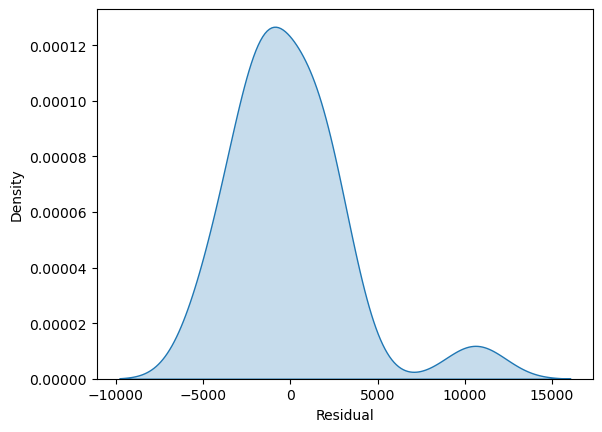

In [64]:
sns.kdeplot(df_residual['Residual'], fill=True)

<Axes: ylabel='Residual'>

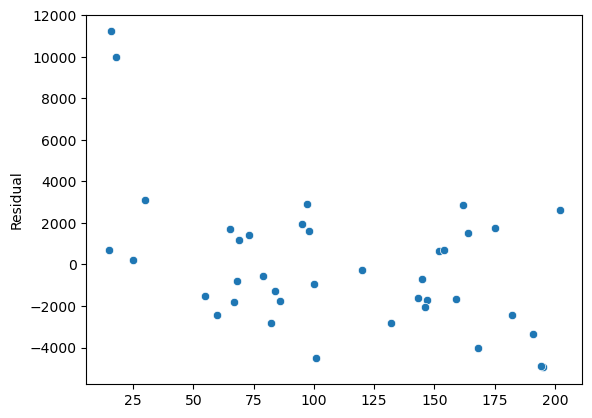

In [65]:
# Assumption of Homoscadasticity
sns.scatterplot(df_residual['Residual'])

In [67]:
import pickle

In [68]:
with open("auto_price_model.pkl", "wb") as file:
    pickle.dump(linear_model, file)
print("Model saved successfully!")

Model saved successfully!


## Load Pickle File & Predict Price

In [71]:
import pickle
import numpy as np

# Load saved model
with open("auto_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# You need to provide all 22 features that the model was trained on
# This is just an example - you'll need to adjust based on your actual training features
new_data = np.array([[
    88.6,    # engine_size
    168.8,   # horsepower  
    64.1,    # curb_weight
    2548,    # feature_4
    4,       # feature_5
    130,     # feature_6
    3.47,    # feature_7
    111.0,   # highway_mpg
    21,      # feature_9
    27,      # feature_10
    0,       # feature_11 (add missing features)
    0,       # feature_12
    0,       # feature_13
    0,       # feature_14
    0,       # feature_15
    0,       # feature_16
    0,       # feature_17
    0,       # feature_18
    0,       # feature_19
    0,       # feature_20
    0,       # feature_21
    0        # feature_22
]])

# Predict price
predicted_price = loaded_model.predict(new_data)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: -443810.57193393423
